In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'
results_path = project_path + '/results'

print("SERIAL 20 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))
print("Labels file exists:", os.path.exists(labels_path))
print("PyTorch version:", torch.__version__)

Mounted at /content/drive
SERIAL 20 loaded successfully.
Project folder exists: True
Train folder exists: True
Test folder exists: True
Labels file exists: True
PyTorch version: 2.11.0+cpu


#Load A-8 telemetry

In [2]:
channel = "A-8"

# Load training and test data
train_A8 = np.load(train_path + "/" + channel + ".npy")
test_A8 = np.load(test_path + "/" + channel + ".npy")

# Use the first telemetry feature
train_telemetry_A8 = train_A8[:, 0]
test_telemetry_A8 = test_A8[:, 0]

print("Channel:", channel)
print("Training data shape:", train_A8.shape)
print("Test data shape:", test_A8.shape)
print("Training telemetry shape:", train_telemetry_A8.shape)
print("Test telemetry shape:", test_telemetry_A8.shape)

print("\nTraining range:")
print("Min:", train_telemetry_A8.min())
print("Max:", train_telemetry_A8.max())

print("\nTest range:")
print("Min:", test_telemetry_A8.min())
print("Max:", test_telemetry_A8.max())

Channel: A-8
Training data shape: (762, 25)
Test data shape: (8375, 25)
Training telemetry shape: (762,)
Test telemetry shape: (8375,)

Training range:
Min: -1.0
Max: 0.9999999999999996

Test range:
Min: -1.0
Max: 1.0000000000000002


###Prepare PyTorch tensors

In [3]:
# Convert telemetry to float32
X_train_A8 = train_telemetry_A8.astype(np.float32).reshape(-1, 1)
X_test_A8 = test_telemetry_A8.astype(np.float32).reshape(-1, 1)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_A8)
X_test_tensor = torch.tensor(X_test_A8)

print("Training tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)
print("Tensor data type:", X_train_tensor.dtype)

Training tensor shape: torch.Size([762, 1])
Test tensor shape: torch.Size([8375, 1])
Tensor data type: torch.float32


###Define the Autoencoder

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


autoencoder = Autoencoder()

print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)


###Prepare Training

Now we create:

DataLoader → sends training data in small batches.

MSELoss → measures reconstruction error.

Adam optimizer → updates the network weights.

In [5]:
torch.manual_seed(42)

# Create training dataset
train_dataset = TensorDataset(X_train_tensor)

# Load data in batches
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

print("Training samples:", len(train_dataset))
print("Batch size:", 32)
print("Loss function: MSE")
print("Optimizer: Adam")

Training samples: 762
Batch size: 32
Loss function: MSE
Optimizer: Adam


##Train the Autoencoder

Now we actually train the model. We'll use 100 epochs.

In [6]:
num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    autoencoder.train()
    epoch_loss = 0.0

    for (batch,) in train_loader:
        # Clear previous gradients
        optimizer.zero_grad()

        # Reconstruct the input
        reconstructed = autoencoder(batch)

        # Calculate reconstruction error
        loss = criterion(reconstructed, batch)

        # Update the model
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch.size(0)

    # Average loss for this epoch
    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [10/100], Loss: 0.940662
Epoch [20/100], Loss: 0.441171
Epoch [30/100], Loss: 0.156522
Epoch [40/100], Loss: 0.082730
Epoch [50/100], Loss: 0.040510
Epoch [60/100], Loss: 0.017967
Epoch [70/100], Loss: 0.007077
Epoch [80/100], Loss: 0.002425
Epoch [90/100], Loss: 0.000707
Epoch [100/100], Loss: 0.000172


Here we can see that The loss dropped from 0.94 → 0.000172, so the Autoencoder learned to reconstruct the training telemetry very well.

##Visualize Training Loss

Now let's see the learning curve.

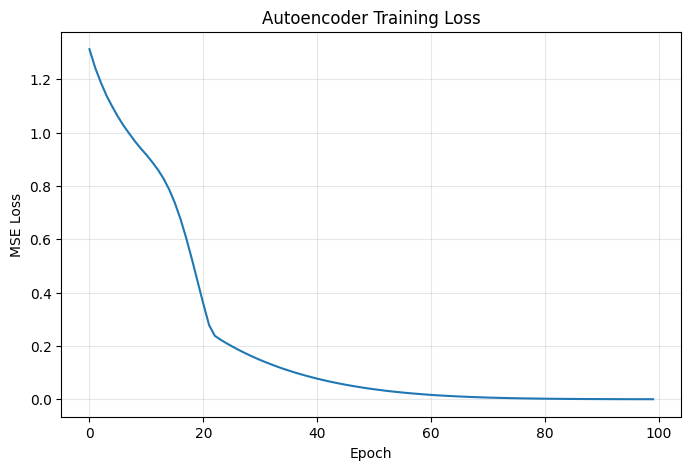

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)
plt.show()

##Calculate Reconstruction Errors

Now we test how well the trained Autoencoder reconstructs both training and test telemetry.

In [8]:
autoencoder.eval()

with torch.no_grad():
    train_reconstructed = autoencoder(X_train_tensor)
    test_reconstructed = autoencoder(X_test_tensor)

# Calculate reconstruction error for each observation
train_errors = torch.mean(
    (X_train_tensor - train_reconstructed) ** 2,
    dim=1
).numpy()

test_errors = torch.mean(
    (X_test_tensor - test_reconstructed) ** 2,
    dim=1
).numpy()

print("Training reconstruction errors:", train_errors.shape)
print("Test reconstruction errors:", test_errors.shape)

print("\nTraining error:")
print("Mean:", train_errors.mean())
print("Max:", train_errors.max())

print("\nTest error:")
print("Mean:", test_errors.mean())
print("Max:", test_errors.max())

Training reconstruction errors: (762,)
Test reconstruction errors: (8375,)

Training error:
Mean: 0.00015887473
Max: 0.00042179364

Test error:
Mean: 0.012442862
Max: 0.11812923


The model reconstructs the training data extremely well, while the test data has much larger reconstruction errors:

Training mean error: 0.000159

Test mean error: 0.01244

Test maximum error: 0.1181

So the Autoencoder is behaving as expected: some test observations are much harder to reconstruct.

However, we cannot call those observations anomalies yet. We need a threshold.

##Choose an Anomaly Threshold

We'll use the 99th percentile of the training reconstruction errors.

In [9]:
# Set threshold using only normal training reconstruction errors
threshold = np.percentile(train_errors, 99)

print("Anomaly threshold:", threshold)

# Create binary anomaly predictions
y_pred_autoencoder_A8 = (test_errors > threshold).astype(int)

print("\nPredicted normal:", np.sum(y_pred_autoencoder_A8 == 0))
print("Predicted anomalies:", np.sum(y_pred_autoencoder_A8 == 1))

Anomaly threshold: 0.00042179364

Predicted normal: 1648
Predicted anomalies: 6727


This result is actually very useful for our research. It shows that the Autoencoder is extremely sensitive with this simple setup.

The training maximum error is only 0.000422, so almost any test point with a larger reconstruction error is classified as anomalous. That's why it predicts 6,727 / 8,375 test points as anomalies.

#Evaluate Autoencoder

In [10]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Ground-truth labels for A-8
y_true_A8 = np.zeros(len(test_telemetry_A8), dtype=int)

anomaly_start = 4569
anomaly_end = 8374

y_true_A8[anomaly_start:anomaly_end + 1] = 1

# Calculate metrics
precision = precision_score(
    y_true_A8,
    y_pred_autoencoder_A8,
    zero_division=0
)

recall = recall_score(
    y_true_A8,
    y_pred_autoencoder_A8,
    zero_division=0
)

f1 = f1_score(
    y_true_A8,
    y_pred_autoencoder_A8,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_true_A8,
    y_pred_autoencoder_A8
).ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("Autoencoder Evaluation — A-8")
print("--------------------------------")
print(f"Precision:           {precision:.6f}")
print(f"Recall:              {recall:.6f}")
print(f"F1-score:            {f1:.6f}")
print(f"False Positive Rate: {false_positive_rate:.6f}")
print(f"False Negative Rate: {false_negative_rate:.6f}")

print("\nConfusion Matrix")
print("----------------")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

Autoencoder Evaluation — A-8
--------------------------------
Precision:           0.320945
Recall:              0.567262
F1-score:            0.409950
False Positive Rate: 0.999781
False Negative Rate: 0.432738

Confusion Matrix
----------------
TN: 1
FP: 4568
FN: 1647
TP: 2159


| Metric              |     Result |
| ------------------- | ---------: |
| Precision           |      0.321 |
| Recall              |      0.567 |
| F1                  |      0.410 |
| False Positive Rate | **0.9998** |
| False Negative Rate |      0.433 |

The 1D Autoencoder detected a substantial portion of the labeled anomalies, achieving 56.7% recall. However, its false-positive rate was approximately 100%, indicating that reconstruction error based on a single raw telemetry feature is insufficient for reliable anomaly detection on A-8.


##Save Autoencoder Result

In [12]:
autoencoder_result = pd.DataFrame([{
    "channel": "A-8",
    "method": "Autoencoder",
    "threshold_method": "99th percentile of training reconstruction error",
    "threshold": threshold,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "false_positive_rate": false_positive_rate,
    "false_negative_rate": false_negative_rate,
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp
}])

output_file = results_path + "/autoencoder_evaluation_A8.csv"

autoencoder_result.to_csv(output_file, index=False)

print("Saved:", output_file)
display(autoencoder_result)

Saved: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/autoencoder_evaluation_A8.csv


,channel,method,threshold_method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Autoencoder,99th percentile of training reconstruction error,0.000422,0.320945,0.567262,0.40995,0.999781,0.432738,1,4568,1647,2159


The 1D Autoencoder detected a substantial portion of the labeled anomalies, but produced an extremely high false-positive rate. This indicates that reconstruction error from a single raw telemetry value is insufficient for reliable detection of the contextual anomaly in A-8.

#github commit

In [13]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (29/29), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb
	modified:   notebooks/14_rolling_zscore.ipynb
	modified:   notebooks/15_compare_statistical_methods.ipynb
	modified:   notebooks/16_isolation_forest.ipynb
	modified:   notebooks/17_evaluate_isolation_forest.ipynb
	modified:   notebooks/18_one_class_svm.ipynb
	modified:   notebooks/19_compare_classical_methods.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/20_autoencoder.ipynb
	results/autoencoder_evaluation_A8.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [14]:
!git add notebooks/20_autoencoder.ipynb results/autoencoder_evaluation_A8.csv

!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

!git commit -m "Complete SERIAL 20 Autoencoder"

[main d513891] Complete SERIAL 20 Autoencoder
 2 files changed, 3 insertions(+)
 create mode 100644 notebooks/20_autoencoder.ipynb
 create mode 100644 results/autoencoder_evaluation_A8.csv


In [15]:
!git push origin main

Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 33.03 KiB | 3.67 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   18ca216..d513891  main -> main
